In [1]:
import warnings
warnings.filterwarnings("ignore")


Целью данной работы является предсказание площади, которая окажется выгоревшей в результате лесных пожаров в северо-восточном регионе Португалии, т.е. мы имеем дело с задачей регрессии

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import torch
import torch.nn as nn
from tqdm.notebook import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.manifold import TSNE

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score, train_test_split, ParameterGrid, KFold, GridSearchCV

# EDA

In [3]:
dataset = pd.read_csv('/content/drive/MyDrive/forestfires.csv')

Проведем описание всех переменных, взятое из документации UCI:
1) X - Пространственная координата по оси x на карте парка Монтезинью: от 1 до 9.
2) Y - Пространственная координата по оси x на карте парка Монтезинью: от 2 до 9.
3) индекс FFMC: от 0,0 до 100,0 -- Численный показатель содержания влаги в мелком опаде и в других твердых мелких в горючих материалах, этот код указывает на относительную легкость зажигания и воспламеняемости мелких горючих материалов.
4) индекс DMC: 1,1 до 300,0 -- Численный показатель среднего содержания влаги неуплотненной органической подстилки на средней глубине, этот код обозначает величину сгорающего горючего материала и древесных материалов среднего размера в средних слоях подстилки.
5) индекс DC: от 7,9 до 890,0 -- Численный показатель среднего содержания влаги в глубокой, уплотненной органической подстилке. Этот код указывает на сезонное воздействие засухи на ЛГМ и величину тления в глубокой подстилке и больших бревнах.
6) индекс ISI: от 0,0 до 60,0 -- Численный показатель ожидаемой скорости распространения пожара. Он объединяет влияния ветра и КВМ ЛГМ на скорость распространения, но исключает влияние изменяющегося количества горючих материалов.
7) temp: температура в градусах Цельсия: от 2.2 до 33.
8) RH: относительная влажность воздуха в %: от 15,0 до 100
9) wind – скорость ветра в км/ч: от 0,4 до 9.4.
10) дождь в мм/м2 : от 0,0 до 6.4.
11) SA – солнечная радиация в кВч/м2: от 1,0 до 6.4
12) площадь сгоревшего участка местности (в га): от 0,00 до 1090,0.

In [4]:
dataset.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [5]:
dataset.describe()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000


У нас имеется 2 категориальных признака: месяц и день недели. Для признаков такого рода является оптимальным использовать циклическое кодирование:

$$
u \to \left[ \sin\left(\frac{2\pi \cdot u}{\max(u)}\right); \cos\left(\frac{2\pi \cdot u}{\max(u)}\right) \right]
$$

где u означает значение некоторого признака, а max(u) -- максимальное значение, которое он может принимать, например 12 для месяцев.
Однако, мы оставим и исходный dataset, так как для работы с категориальными признаками мы сможем использовать различные бустинги и случайный лес. Кодирование же нам нужно будет, чтобы спокойно использовать линейную регрессию и другие методы, которые не умеют работать с категориальными признаками.


Заменим сначала названия месяцев и дней недели на их порядковый номер

In [6]:
print(*dataset['month'].unique())
print(*dataset['day'].unique())

mar oct aug sep apr jun jul feb jan dec may nov
fri tue sat sun mon wed thu


In [7]:
data = dataset.copy()
numpy_months = (data['month'] == 'mar').to_numpy()
mapping = {'jan': 1, 'feb' : 2, 'mar' : 3, 'apr' : 4, 'may' : 5, 'jun' : 6,
           'jul' : 7, 'aug' : 8, 'sep' : 9, 'oct' :10, 'nov' : 11, 'dec' : 12}
ser = (data['month'].map(mapping))
data['month'] = ser
mapping = {'mon':1, 'tue':2, 'wed':3, 'thu':4, 'fri' :5, 'sat':6, 'sun':7}
ser = data['day'].map(mapping)
data['day'] = ser
data

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,3,5,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.00
1,7,4,10,2,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.00
2,7,4,10,6,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.00
3,8,6,3,5,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.00
4,8,6,3,7,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,8,7,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44
513,2,4,8,7,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29
514,7,4,8,7,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,11.16
515,1,4,8,6,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,0.00


In [8]:
ser = data['month']
ser_sin = np.sin(2*np.pi*(ser.to_numpy())/12)
data.insert(loc = 3, column = 'month_sin', value = ser_sin)
ser_cos = np.cos(2*np.pi*(ser.to_numpy())/12)
data.insert(loc = 4, column = 'month_cos', value = ser_cos)


In [9]:
ser = data['day']
ser_sin = np.sin(2*np.pi*(ser.to_numpy())/12)
data.insert(loc = 5, column = 'day_sin', value = ser_sin)
ser_cos = np.cos(2*np.pi*(ser.to_numpy())/12)
data.insert(loc = 6, column = 'day_cos', value = ser_cos)


Удалим теперь старые переменные


In [10]:
data.drop(labels=['month', 'day'], axis =1, inplace = True)

In [11]:
data

,X,Y,month_sin,month_cos,day_sin,day_cos,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,1.000000,6.123234e-17,5.000000e-01,-0.866025,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.00
1,7,4,-0.866025,5.000000e-01,8.660254e-01,0.500000,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.00
2,7,4,-0.866025,5.000000e-01,1.224647e-16,-1.000000,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.00
3,8,6,1.000000,6.123234e-17,5.000000e-01,-0.866025,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.00
4,8,6,1.000000,6.123234e-17,-5.000000e-01,-0.866025,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,-0.866025,-5.000000e-01,-5.000000e-01,-0.866025,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44
513,2,4,-0.866025,-5.000000e-01,-5.000000e-01,-0.866025,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29
514,7,4,-0.866025,-5.000000e-01,-5.000000e-01,-0.866025,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,11.16
515,1,4,-0.866025,-5.000000e-01,1.224647e-16,-1.000000,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,0.00


Давайте теперь построи м матрицу корреляций

In [12]:
corr_matrix = data.corr()
(corr_matrix['area'][:-1]).sort_values(ascending=False)

,area
temp,0.097844
DMC,0.072994
X,0.063385
DC,0.049383
Y,0.044873
FFMC,0.040122
wind,0.012317
ISI,0.008258
month_cos,-0.001847
rain,-0.007366


Видим, что сильной корреляции между area и каким-либо признаком не обнаруживается.

Но для того, чтобы убедиться в этом наверняка строим heatmap для матрицы корреляций.

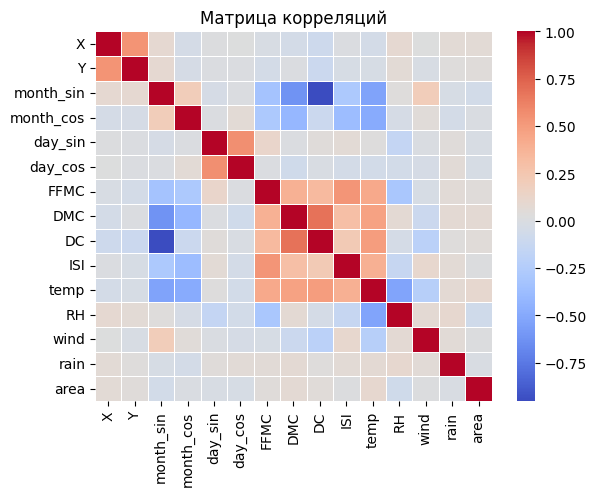

In [13]:
sns.heatmap(corr_matrix,
            cmap='coolwarm',
            linewidths=0.5,
            cbar=True)

plt.title('Матрица корреляций')
plt.show()

Из тепловой карты видно, что, действительно, с площадью возгорания ничего в особенности не коррелирует. Однако, в целом, есть скоррелированные признаки. Из очевидной корреляции month_cos и month_sin. Ну это и понятно, ведь они порождены одним признаком. Но есть и менее очевидные корреляции. Это наталкивает на мысль, что можно пробовать применять метод главных компонент для редцирования размерности пространства признаков.

Поскольку в данных есть некоторое количество выбросов, то мы установим лимиты по оси y -- то есть ограничим area.

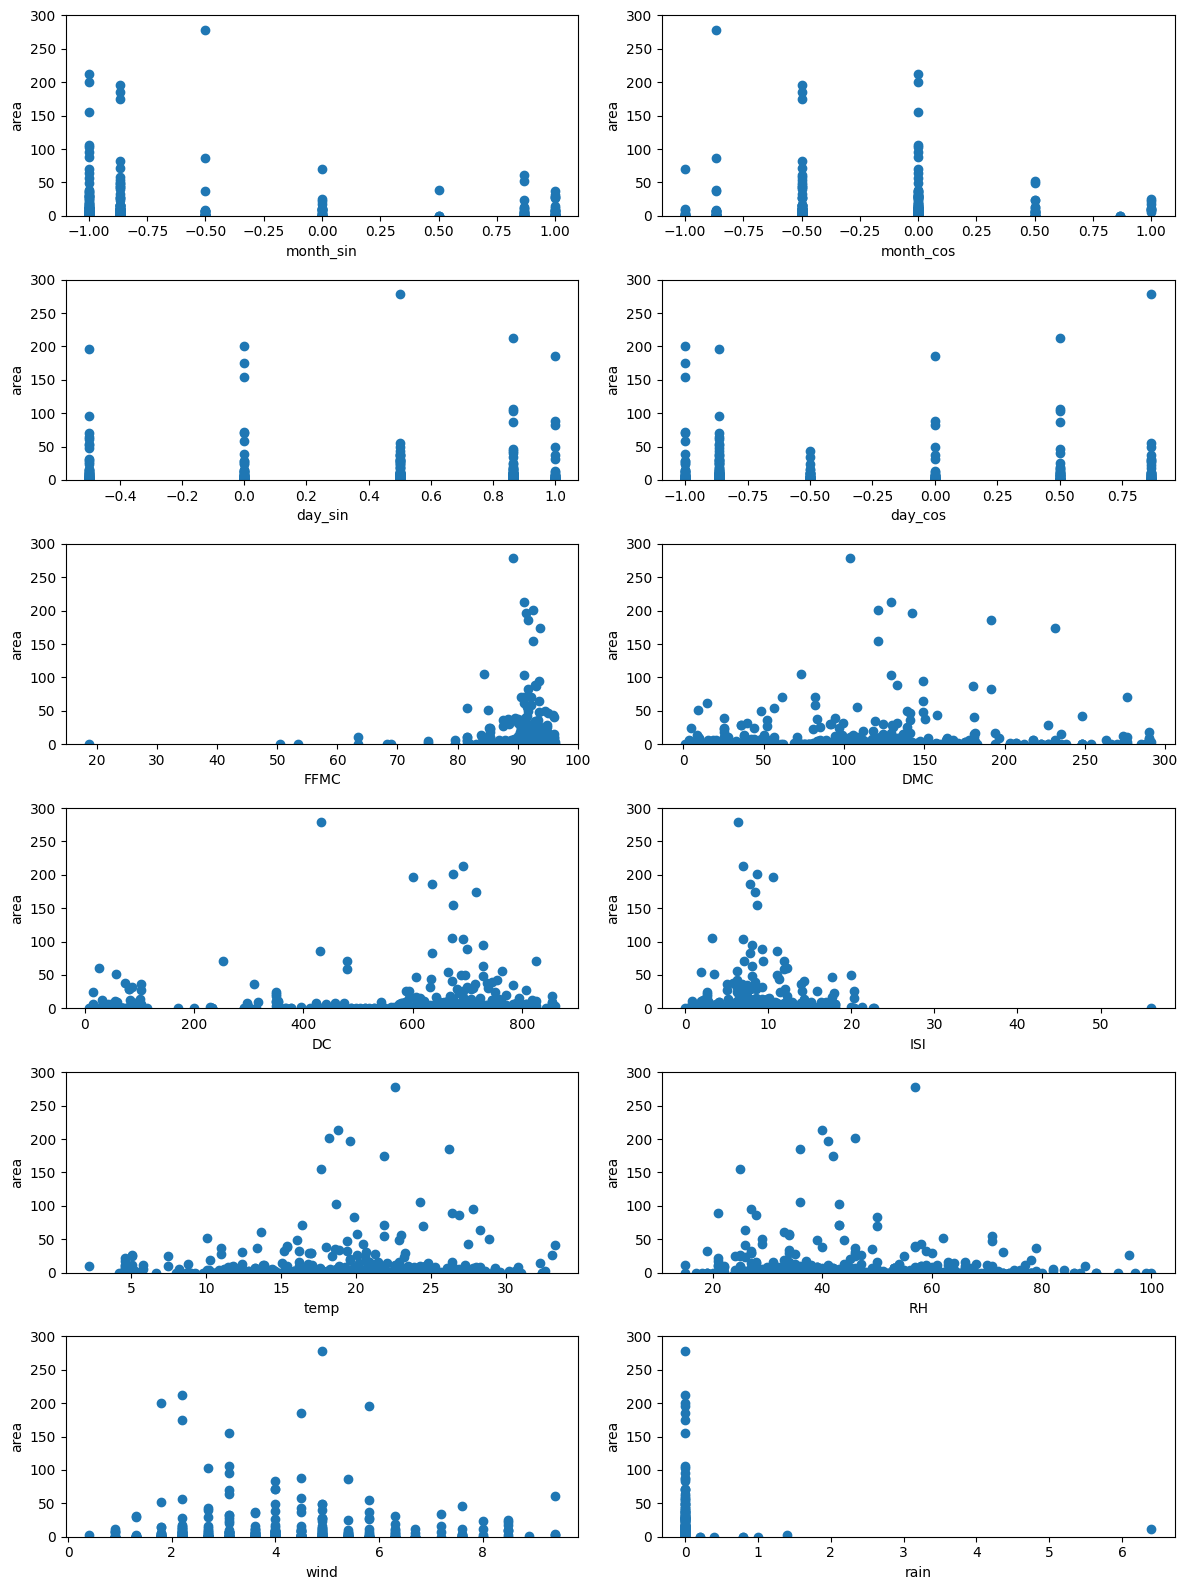

In [14]:
fig, axes = plt.subplots(6, 2, figsize = (12,16))
feat = (data.columns[:-1].to_numpy())[2:14]
for i, ax in enumerate(axes.ravel()):
  ax.scatter(data=data, x = feat[i], y ='area')

  ax.set_xlabel(feat[i])
  ax.set_ylabel('area')
  ax.set_ylim(0,300)
plt.tight_layout()
plt.show()

Видим, что также есть выброс по rain. Уберем и его


In [15]:
data_filtered = data[data['area'] <=300]
data_filtered = data_filtered[data_filtered['rain'] <=3]
data_filtered.describe()

,X,Y,month_sin,month_cos,day_sin,day_cos,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,514.000000,514.000000,514.000000,5.140000e+02,5.140000e+02,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000
mean,4.655642,4.293774,-0.538895,-2.195463e-01,3.745547e-01,-0.337157,90.622374,110.498833,547.161089,9.002724,18.843969,44.319066,4.014202,0.009339,9.327062
std,2.312795,1.230414,0.704317,4.081884e-01,5.179814e-01,0.692231,5.527291,63.966678,248.578068,4.561688,5.792616,16.308531,1.796035,0.092982,27.377201
min,1.000000,2.000000,-1.000000,-1.000000e+00,-5.000000e-01,-1.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,-1.000000,-5.000000e-01,1.224647e-16,-0.866025,90.200000,63.875000,434.400000,6.425000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,-0.866025,-1.836970e-16,5.000000e-01,-0.866025,91.600000,108.300000,661.800000,8.400000,19.300000,42.000000,4.000000,0.000000,0.495000
75%,7.000000,5.000000,-0.500000,-1.836970e-16,8.660254e-01,0.500000,92.900000,141.300000,713.900000,10.700000,22.775000,53.000000,4.900000,0.000000,6.437500
max,9.000000,9.000000,1.000000,1.000000e+00,1.000000e+00,0.866025,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,1.400000,278.530000


Теперь, когда удалены выбросы, приведем данные к стандратному виду, используя StandardScaler

In [16]:
X = data_filtered.drop(['area'], axis=1)
y = data_filtered['area']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, shuffle=True, random_state = 42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Теперь, как и обещалось выше, применим метод главных компонент.

In [17]:
pca = PCA()
pca.fit(X_train)

# Смотрим объяснённую дисперсию
explained_variance_ratio = pca.explained_variance_ratio_
cumsum = np.cumsum(explained_variance_ratio)

print("Доля дисперсии на каждой компоненте:", explained_variance_ratio)
print("Накопленная доля дисперсии:", cumsum)

Доля дисперсии на каждой компоненте: [0.2656989  0.12525689 0.1138647  0.10284177 0.09015854 0.06277771
 0.06018279 0.04960611 0.03451088 0.03209433 0.02880473 0.02206285
 0.00983527 0.00230454]
Накопленная доля дисперсии: [0.2656989  0.39095578 0.50482048 0.60766225 0.69782079 0.7605985
 0.82078129 0.8703874  0.90489828 0.93699262 0.96579734 0.98786019
 0.99769546 1.        ]


Визуализируем полученный результат


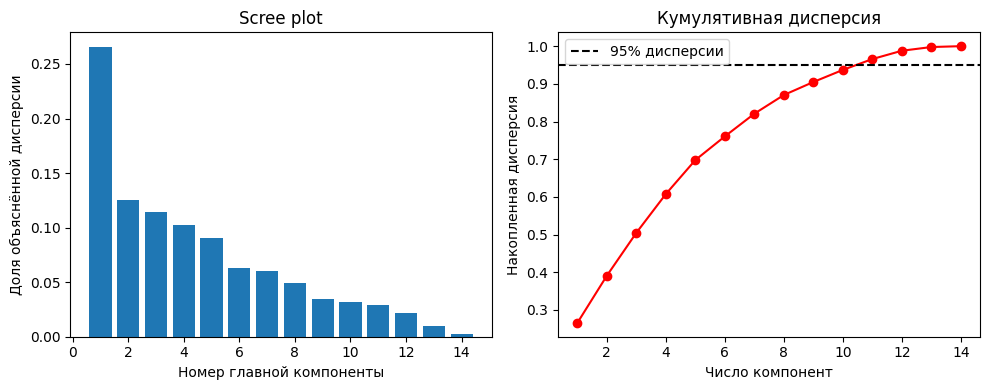

In [18]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_)
plt.xlabel('Номер главной компоненты')
plt.ylabel('Доля объяснённой дисперсии')
plt.title('Scree plot')

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumsum)+1), cumsum, 'ro-')
plt.xlabel('Число компонент')
plt.ylabel('Накопленная дисперсия')
plt.title('Кумулятивная дисперсия')
plt.axhline(y=0.95, color='k', linestyle='--', label='95% дисперсии')
plt.legend()
plt.tight_layout()
plt.show()

На деле оказывается, что смысла делать метод главных компонент никакого нет, поэтому откажемся от этой идеи.  

Для борьбы с мультиколлинеарностью, которая естественным образом возникает, когда мы говорим о FFMC и DMC (оба эти признака характеризует влажность), мы просто будет использовать L1 регуряризацию, чтобы занулить один из признаков.

Кластеризуем наши данные. Это может быть очень полезно для задачи регрессии, так как если получится выделить "хорошую" кластерную структуру, то мы сможем строить регрессию для каждого кластера отдельно, поэтому кластеризация может оказаеться очень полезной в нашем случае.

Метод, которые применим -- это DBSCAN.

In [19]:
dbscan = DBSCAN(eps=2.5, min_samples=5)
labels_db = dbscan.fit_predict(X_train)

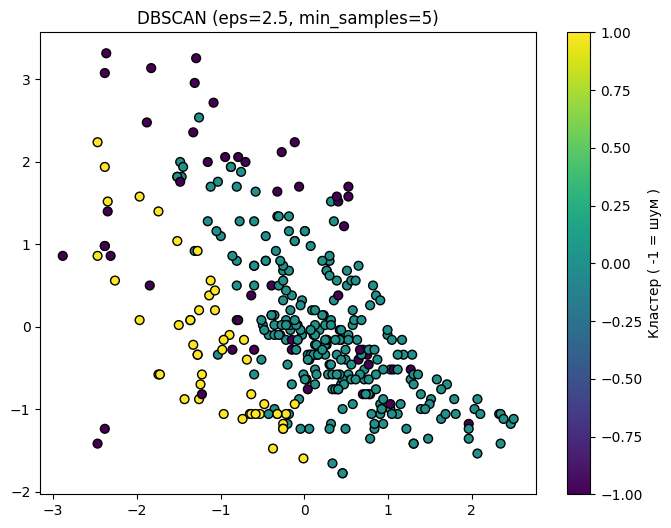

In [20]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train[:, 10], X_train[:, 11],
                      c=labels_db, cmap='viridis', s=40, edgecolors='k')
plt.title(f'DBSCAN (eps=2.5, min_samples=5)')
plt.colorbar(scatter, label='Кластер ( -1 = шум )')
plt.show()

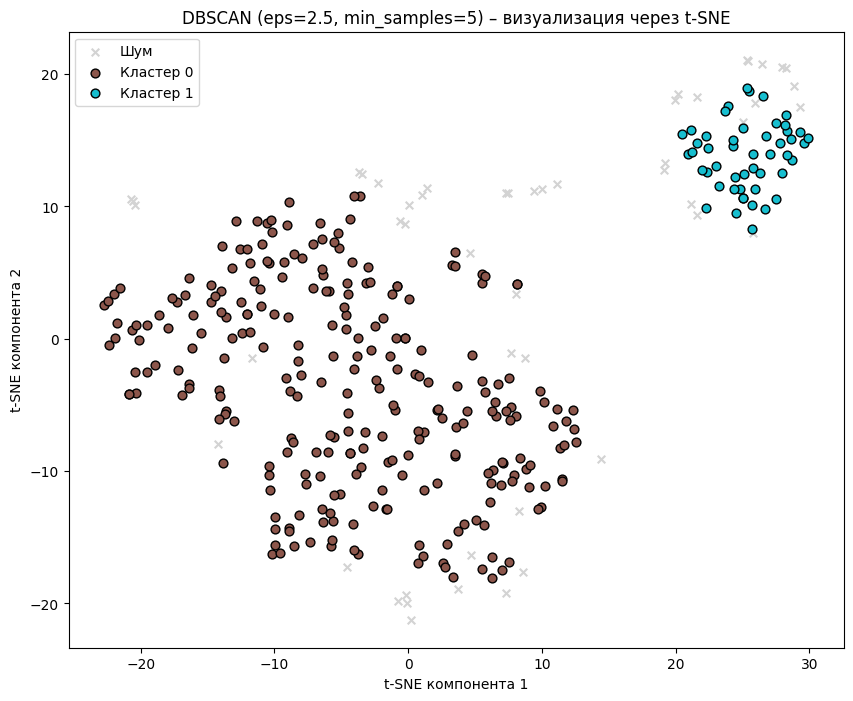

In [21]:
min_samples = 5
eps=2.5
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_train)   # проецируем 8‑мерные данные в 2D

# Визуализируем результат DBSCAN на плоскости t‑SNE
plt.figure(figsize=(10, 8))
# Цветовая схема: шум (метка -1) – серый, остальные кластеры – разные цвета
unique_labels = np.unique(labels_db)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

for label, col in zip(unique_labels, colors):
    if label == -1:
        col = 'lightgray'
        marker = 'x'
        size = 30
        label_txt = 'Шум'
    else:
        marker = 'o'
        size = 40
        label_txt = f'Кластер {label}'

    plt.scatter(X_tsne[labels_db == label, 0], X_tsne[labels_db == label, 1],
                c=[col], marker=marker, s=size, label=label_txt, edgecolors='k')

plt.title(f'DBSCAN (eps={eps}, min_samples={min_samples}) – визуализация через t‑SNE')
plt.xlabel('t‑SNE компонента 1')
plt.ylabel('t‑SNE компонента 2')
plt.legend()
plt.show()

Мы действительно выделили некоторые 2 кластера. В дальнейшем, при обучении моделей, подумаем, как можно этим воспользоваться.

На этом наш разведочный анализ данных подошел к концу. Теперь попробуем подобрать модели, которые бы идеально подошли к нашей задаче

In [25]:
import os
import json
import sys


def clean_notebook(filepath):
    try:
        filepath = os.path.abspath(filepath)
        with open(filepath, "r", encoding="utf-8") as f:
            notebook = json.load(f)

        modified = False
        if "metadata" in notebook and "widgets" in notebook["metadata"]:
            del notebook["metadata"]["widgets"]
            modified = True

        if modified:
            with open(filepath, "w", encoding="utf-8") as f:
                json.dump(notebook, f, indent=2)
            print(f"Cleaned {filepath}")
            return True
        return False
    except Exception as e:
        print(f"Error processing {filepath}: {str(e)}", file=sys.stderr)
        return False

if __name__ == "__main__":
    for path in sys.argv[1:]:
        modified_notebook = clean_notebook(path)
        if modified_notebook:
            print(f"Modified {path}")
        else:
            print(f"No changes to {path}")

No changes to -f
No changes to /root/.local/share/jupyter/runtime/kernel-c33ef43b-d6d0-4923-ba74-03ebf86d2829.json


Error processing /content/-f: [Errno 2] No such file or directory: '/content/-f'


# Подбор моделей (В процессе)